# Question 4

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

In [32]:
order_id = np.arange(1,301)
customer_type = np.random.choice(["Regular","Premium","New"],size=300)
region = np.random.choice(["North","South","East","West"],size=300)
units_sold = np.random.randint(1,11,size=300)
unit_price = np.random.uniform(50,500,size=300).round(2)
order_date = pd.to_datetime(np.random.choice(pd.date_range("2025-02-01","2025-02-28"),size=300))

In [33]:
orders_df = pd.DataFrame({
    "Order_ID":order_id,
    "Region":region,
    "Customer_Type":customer_type,
    "Units_Sold":units_sold,
    "Unit_Price":unit_price,
    "Order_Date":order_date
})
orders_df.head()

,Order_ID,Region,Customer_Type,Units_Sold,Unit_Price,Order_Date
0,1,East,New,1,150.73,2025-02-10
1,2,West,Regular,1,419.81,2025-02-07
2,3,North,New,3,205.29,2025-02-01
3,4,North,New,5,206.43,2025-02-23
4,5,West,Regular,3,64.31,2025-02-21


In [34]:
orders_df["Revenue"] = orders_df["Units_Sold"] * orders_df["Unit_Price"]
orders_df.head()

,Order_ID,Region,Customer_Type,Units_Sold,Unit_Price,Order_Date,Revenue
0,1,East,New,1,150.73,2025-02-10,150.73
1,2,West,Regular,1,419.81,2025-02-07,419.81
2,3,North,New,3,205.29,2025-02-01,615.87
3,4,North,New,5,206.43,2025-02-23,1032.15
4,5,West,Regular,3,64.31,2025-02-21,192.93


In [35]:
n = int(300 * (8/100))
indices = np.random.choice(orders_df.index,size=n,replace=False)
orders_df.loc[indices,"Unit_Price"] = np.nan
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       300 non-null    int64         
 1   Region         300 non-null    object        
 2   Customer_Type  300 non-null    object        
 3   Units_Sold     300 non-null    int32         
 4   Unit_Price     276 non-null    float64       
 5   Order_Date     300 non-null    datetime64[ns]
 6   Revenue        300 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(2)
memory usage: 15.4+ KB


In [36]:
print(orders_df.isna().sum())
unit_price_mean = orders_df["Unit_Price"].mean()
orders_df["Unit_Price"] = orders_df["Unit_Price"].fillna(unit_price_mean)
orders_df.info()

Order_ID          0
Region            0
Customer_Type     0
Units_Sold        0
Unit_Price       24
Order_Date        0
Revenue           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       300 non-null    int64         
 1   Region         300 non-null    object        
 2   Customer_Type  300 non-null    object        
 3   Units_Sold     300 non-null    int32         
 4   Unit_Price     300 non-null    float64       
 5   Order_Date     300 non-null    datetime64[ns]
 6   Revenue        300 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(2)
memory usage: 15.4+ KB


In [51]:
total_revenue = orders_df.groupby("Region").Revenue.sum()
orders_df.groupby("Customer_Type").Units_Sold.mean()
orders_df.groupby("Order_ID").Revenue.sum().sort_values(ascending=False).head(5)

Order_ID
277    4905.2
83     4887.8
92     4856.0
125    4669.0
200    4634.4
Name: Revenue, dtype: float64

In [52]:
orders_df["Revenue"].mean()
orders_df["Revenue"].median()
orders_df["Revenue"].std()
orders_df["Revenue"].to_numpy()

array([ 150.73,  419.81,  615.87, 1032.15,  192.93,  296.92,  290.49,
       1681.6 , 4524.  ,  215.88,  595.62,  389.42,  274.59, 1865.64,
        359.5 , 2802.5 ,  965.12, 2197.8 ,  511.7 , 4407.4 ,  176.06,
        956.34, 4444.38, 2040.29, 1863.28, 1562.5 , 1959.9 ,  578.14,
       2993.84,  312.2 , 1048.32,  549.5 , 3232.98, 1720.  , 3873.3 ,
        318.55, 3962.25, 1674.96,  686.16,   97.19, 1145.49,  528.12,
        607.56,  428.32,  630.98, 2327.2 , 1084.65, 1021.6 ,  263.29,
       1468.6 , 2393.79, 2392.29,  938.67, 3434.13,  300.98,  313.94,
       1216.04, 1984.05, 1211.1 , 1364.52,  323.4 ,  639.84, 2467.89,
        595.98, 4231.44,  373.73,  605.6 ,  643.23, 2695.1 , 2164.35,
        447.75, 1237.92,  675.36, 1716.16,  366.2 ,  232.84, 1818.15,
       3491.32, 4081.23, 2164.4 , 2314.15,  523.9 , 4887.8 , 1895.88,
       3753.  , 2096.95, 1119.93, 2035.39,  528.96, 3846.24, 1422.8 ,
       4856.  ,  369.93,  838.68, 2669.17, 2307.44, 3682.5 , 3559.5 ,
        178.56, 2777

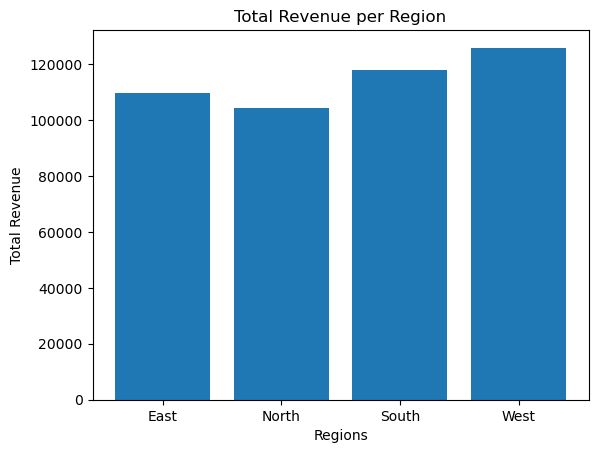

In [56]:
plt.bar(total_revenue.index,total_revenue)
plt.xlabel("Regions")
plt.ylabel("Total Revenue")
plt.title("Total Revenue per Region")
plt.show()

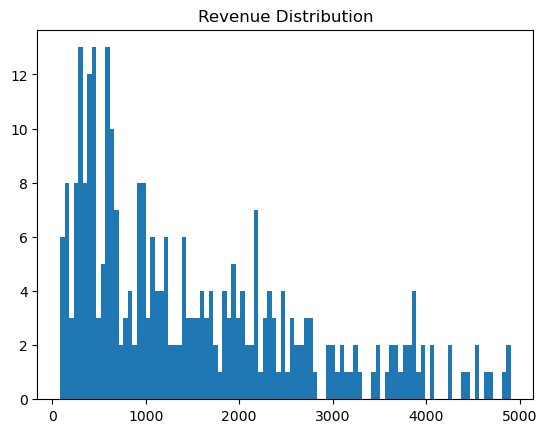

In [61]:
plt.hist(orders_df["Revenue"],bins=100)
plt.title("Revenue Distribution")
plt.show()

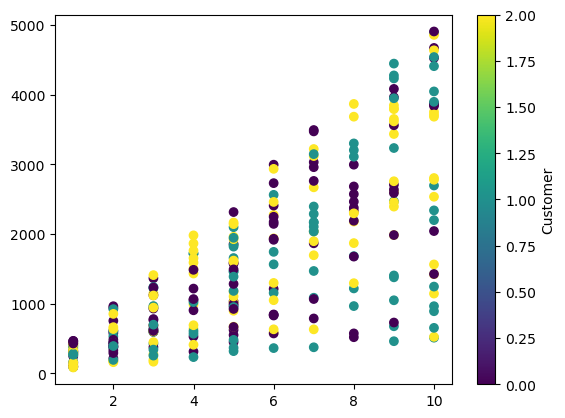

In [77]:
region_codes = orders_df["Customer_Type"].astype("category").cat.codes

plt.scatter(
    orders_df["Units_Sold"],
    orders_df["Revenue"],
    c=region_codes,
)
plt.colorbar(label="Customer")
plt.show()